In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 200)

df_annotators = pd.read_csv("from_annotators.csv")
df_golden = pd.read_csv("hate_speech_gold_sample.csv")

print(df_annotators.shape)
print(df_golden.shape)

df_annotators.head()

(1000, 4)
(1000, 3)


,text,annotator_1,annotator_2,annotator_3
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,No,no,Yes
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",Yes,yes,Yes
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",No,no,Yes
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",No,no,Yes
4,Hate it jab test ata ho phr bh acha na ho -.-,Yes,yes,Yes


In [ ]:
df_golden.head()

,Unnamed: 0,text,is_hate_speech
0,0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no
1,1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",no
2,2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no
3,3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",yes
4,4,Hate it jab test ata ho phr bh acha na ho -.-,yes


In [ ]:
df_annotators.columns = df_annotators.columns.str.strip().str.lower()
df_golden.columns = df_golden.columns.str.strip().str.lower()

df_golden = df_golden.drop(columns=["unnamed: 0"], errors="ignore")


In [ ]:
def normalize_label(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower()

for col in ["annotator_1", "annotator_2", "annotator_3"]:
    df_annotators[col] = df_annotators[col].apply(normalize_label)

df_golden["is_hate_speech"] = df_golden["is_hate_speech"].apply(normalize_label)

In [ ]:
df = df_annotators.merge(
    df_golden,
    on="text",
    how="inner"
)

df = df.rename(columns={
    "is_hate_speech": "gold_label"
})

print(df.shape)
df.head()

(1000, 5)


,text,annotator_1,annotator_2,annotator_3,gold_label
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no,no,yes,no
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",yes,yes,yes,no
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no,no,yes,no
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",no,no,yes,yes
4,Hate it jab test ata ho phr bh acha na ho -.-,yes,yes,yes,yes


In [ ]:
df.to_csv("merged_data.csv")

In [ ]:
df = pd.read_csv("merged_data.csv")
df.drop("Unnamed: 0",axis=1,inplace=True)

In [ ]:
df.isnull().sum()


,0
text,1
annotator_1,0
annotator_2,0
annotator_3,0
gold_label,0


In [ ]:
df = df.dropna(subset=[
    'text',"annotator_1", "annotator_2", "annotator_3", "gold_label"
])

df["char_len"] = df["text"].apply(len)
df["word_len"] = df["text"].apply(lambda x: len(x.split()))

df[["char_len", "word_len"]].describe()

,char_len,word_len
count,999.000000,999.000000
mean,113.905906,21.301301
std,59.951560,11.288897
min,13.000000,3.000000
25%,69.000000,13.000000
50%,108.000000,20.000000
75%,139.000000,26.500000
max,341.000000,63.000000


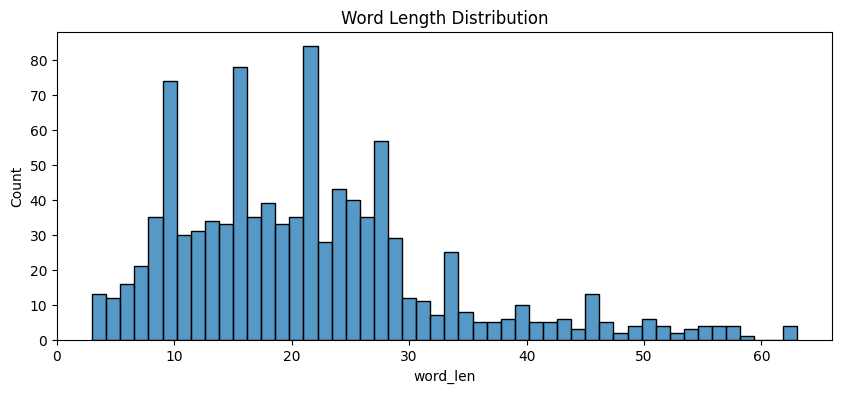

In [ ]:
plt.figure(figsize=(10,4))
sns.histplot(df["word_len"], bins=50)
plt.title("Word Length Distribution")
plt.show()

In [ ]:
label_cols = ["annotator_1", "annotator_2", "annotator_3", "gold_label"]

for col in label_cols:
    print("\n", col)
    print(df[col].value_counts(normalize=True))


 annotator_1
annotator_1
no     0.527528
yes    0.472472
Name: proportion, dtype: float64

 annotator_2
annotator_2
no     0.620621
yes    0.379379
Name: proportion, dtype: float64

 annotator_3
annotator_3
yes    0.77978
no     0.22022
Name: proportion, dtype: float64

 gold_label
gold_label
no     0.707708
yes    0.292292
Name: proportion, dtype: float64


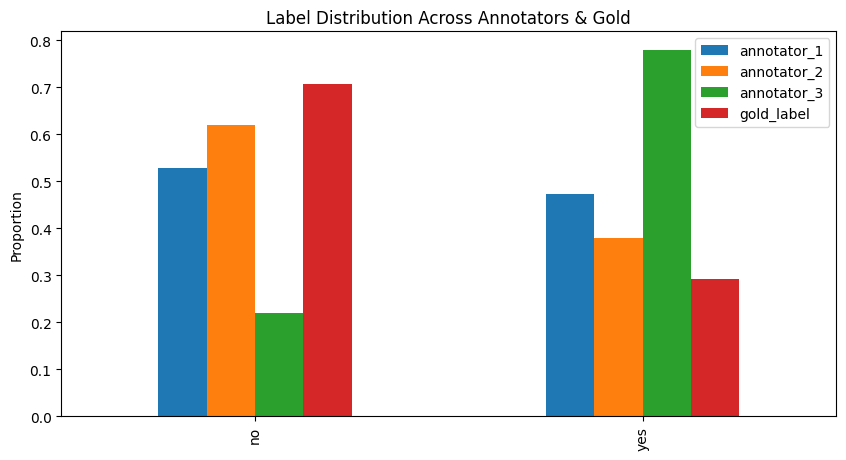

In [ ]:
# Label distribution per annotator
label_dist = pd.DataFrame({
    col: df[col].value_counts(normalize=True)
    for col in label_cols
}).fillna(0)

label_dist.plot(kind="bar", figsize=(10,5))
plt.title("Label Distribution Across Annotators & Gold")
plt.ylabel("Proportion")
plt.show()

In [ ]:
# Majority vote
df["majority_label"] = df[
    ["annotator_1", "annotator_2", "annotator_3"]
].mode(axis=1)[0]

In [ ]:
df["num_yes"] = (
    (df["annotator_1"] == "yes").astype(int) +
    (df["annotator_2"] == "yes").astype(int) +
    (df["annotator_3"] == "yes").astype(int)
)

df["disagreement"] = df["num_yes"].apply(
    lambda x: 1 if x in [1,2] else 0
)

df["disagreement"].value_counts(normalize=True)

,proportion
disagreement,
0,0.562563
1,0.437437


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\u0900-\u097F\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(5)

,text,clean_text
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",doctor sab sahi me ke phd in hate politics wale bhai padhe likhe ho fir kyu ye sab baate karte ho tum bas bowling khelo aur maje lo pic twitter com fk qubqstw
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",poore desh me patel obc me aate hain sirf gujrat ko chor kar may be ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis obc ko mila hai usse bhi nafrat karte hain ye khoon aur ch...
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",sarkar banne ke bad hindu hit me ek bhi faisla jo bjp ke dwara liya gaya ho bjp ko gay gobar mandir masjid aur nafrat faila kar vot chahiye
4,Hate it jab test ata ho phr bh acha na ho -.-,hate it jab test ata ho phr bh acha na ho


In [ ]:
label_map = {"no": 0, "yes": 1}

for col in label_cols + ["majority_label"]:
    df[col + "_bin"] = df[col].map(label_map)

In [ ]:
df["label_distribution"] = df.apply(
    lambda row: [
        row["annotator_1_bin"],
        row["annotator_2_bin"],
        row["annotator_3_bin"]
    ],
    axis=1
)

In [ ]:
df["gold_vs_majority_mismatch"] = (
    df["gold_label_bin"] != df["majority_label_bin"]
).astype(int)

df["gold_vs_majority_mismatch"].value_counts(normalize=True)

,proportion
gold_vs_majority_mismatch,
0,0.684685
1,0.315315


In [ ]:
final_cols = [
    "text",
    "clean_text",
    "annotator_1_bin",
    "annotator_2_bin",
    "annotator_3_bin",
    "gold_label_bin",
    "majority_label_bin",
    "disagreement"
]

final_df = df[final_cols]
final_df.head()

,text,clean_text,annotator_1_bin,annotator_2_bin,annotator_3_bin,gold_label_bin,majority_label_bin,disagreement
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and,0,0,1,0,0,1
1,"Doctor sab sahi me ke PhD (in hate politics) wale. Bhai padhe likhe ho fir kyu ye sab baate karte ho. Tum bas bowling khelo, aur maje lo. pic.twitter.com/fk1qUbQstw",doctor sab sahi me ke phd in hate politics wale bhai padhe likhe ho fir kyu ye sab baate karte ho tum bas bowling khelo aur maje lo pic twitter com fk qubqstw,1,1,1,0,1,0
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",poore desh me patel obc me aate hain sirf gujrat ko chor kar may be ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis obc ko mila hai usse bhi nafrat karte hain ye khoon aur ch...,0,0,1,0,0,1
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",sarkar banne ke bad hindu hit me ek bhi faisla jo bjp ke dwara liya gaya ho bjp ko gay gobar mandir masjid aur nafrat faila kar vot chahiye,0,0,1,1,0,1
4,Hate it jab test ata ho phr bh acha na ho -.-,hate it jab test ata ho phr bh acha na ho,1,1,1,1,1,0


In [ ]:
LABEL_MAP = {
    "yes": 1,
    "no": 0
}

label_cols = ["annotator_1", "annotator_2", "annotator_3", "gold_label"]

for col in label_cols:
    df[col] = df[col].str.strip().str.lower()
    df[col + "_bin"] = df[col].map(LABEL_MAP)

In [ ]:
df[label_cols + [c + "_bin" for c in label_cols]].head()

,annotator_1,annotator_2,annotator_3,gold_label,annotator_1_bin,annotator_2_bin,annotator_3_bin,gold_label_bin
0,no,no,yes,no,0,0,1,0
1,yes,yes,yes,no,1,1,1,0
2,no,no,yes,no,0,0,1,0
3,no,no,yes,yes,0,0,1,1
4,yes,yes,yes,yes,1,1,1,1


In [ ]:
# Cohen’s Kappa pairwise

from sklearn.metrics import cohen_kappa_score

annotator_pairs = [
    ("annotator_1_bin", "annotator_2_bin"),
    ("annotator_1_bin", "annotator_3_bin"),
    ("annotator_2_bin", "annotator_3_bin"),
]

for a, b in annotator_pairs:
    kappa = cohen_kappa_score(df[a], df[b])
    print(f"Cohen Kappa ({a} vs {b}): {kappa:.4f}")


Cohen Kappa (annotator_1_bin vs annotator_2_bin): 0.7991
Cohen Kappa (annotator_1_bin vs annotator_3_bin): 0.2950
Cohen Kappa (annotator_2_bin vs annotator_3_bin): 0.2733


In [ ]:
#fleiss kappa

from statsmodels.stats.inter_rater import fleiss_kappa

def fleiss_matrix(df, cols):
    matrix = []
    for _, row in df[cols].iterrows():
        counts = [0, 0]
        for val in row:
            counts[val] += 1
        matrix.append(counts)
    return np.array(matrix)

fk_matrix = fleiss_matrix(
    df,
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
)

fleiss_kappa(fk_matrix)


np.float64(0.4122237132047699)

In [ ]:
!pip install krippendorff

In [ ]:
# Krippendorff’s Alpha
import krippendorff

alpha = krippendorff.alpha(
    reliability_data=df[
        ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
    ].values.T,
    level_of_measurement="nominal"
)

alpha

np.float64(0.412419834755252)

In [ ]:
from sklearn.metrics import confusion_matrix

for col in ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]:
    cm = confusion_matrix(df["gold_label_bin"], df[col])
    print(f"\nConfusion Matrix: Gold vs {col}")
    print(cm)


Confusion Matrix: Gold vs annotator_1_bin
[[450 257]
 [ 77 215]]

Confusion Matrix: Gold vs annotator_2_bin
[[527 180]
 [ 93 199]]

Confusion Matrix: Gold vs annotator_3_bin
[[202 505]
 [ 18 274]]


In [ ]:
df["majority_label_bin"] = df[
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
].mode(axis=1)[0]

In [ ]:
df["num_yes"] = df[
    ["annotator_1_bin", "annotator_2_bin", "annotator_3_bin"]
].sum(axis=1)

df["disagreement"] = df["num_yes"].apply(
    lambda x: 1 if x in [1, 2] else 0
)

df["disagreement"].value_counts(normalize=True)

,proportion
disagreement,
0,0.562563
1,0.437437


In [ ]:
ambiguous_cases = df[df["disagreement"] == 1]

ambiguous_cases[
    ["text", "annotator_1", "annotator_2", "annotator_3"]
].head(10)

,text,annotator_1,annotator_2,annotator_3
0,I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi Deni chahye .. Proud to be a #Muhajir and #Pakistani,no,no,yes
2,"Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi aapko aarackchan nahi denge ye to jis OBC Ko Mila hai usse bhi nafrat karte hain ye khoon aur c...",no,no,yes
3,"Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko gay,gobar,mandir,masjid aur nafrat faila kar vot chahiye",no,no,yes
5,Ek dil ek jaan akal ke imitihaan kal KP ke rape aur sawing between two legs after rape honge justified due to cinematic liberty aaj toh Rajput ki ho gayi shaan urdu ki gulaam,no,no,yes
6,Aise logo se sakht nafrat karta hu Jo caste ko naam ke sath jod ke chaude hote h but real me vo piddu hote h,no,no,yes
8,I am very sorry to say saaf dil shilpa ke fans hiten ke dil mein kya hai woh bhi samjhte hain hadh hoti hai nafrat ki bhi,no,no,yes
14,Mehanat to school me copy karke likhne me b lagti hai fir illegal kyu? Atanki ko b lagti hai fir nafrat kyu? Paise lekar ghar ki aurato ka smman bech doge kya paise aur mehanat ke liye aap?,no,no,yes
15,"Ladla wo hay jo fard jurm kay bad bhi girftar nahi hota, money trail nahi deta aur saza nahi milti, 14 murder karta hay aur phansi nahi lagti.",no,no,yes
17,Sir ji ab ye possible nahi hai bahut nafrat hai dono or ab ek hi rasta hai sarhad ke lakir ko mita kar hi ye khatam ho sakta hai jinna sahab to mar gaye or neharu ji bhi ab fir se ek kartay hai do...,yes,no,yes
18,"Code phatta hai toh phatne do, Mujhe project se nafrat ho gayi hai, Mujhe development team se hatne do",no,no,yes


In [ ]:
datasets = {
    "gold": df[["clean_text", "gold_label_bin"]],
    "annotator_1": df[["clean_text", "annotator_1_bin"]],
    "annotator_2": df[["clean_text", "annotator_2_bin"]],
    "annotator_3": df[["clean_text", "annotator_3_bin"]],
    "majority": df[["clean_text", "majority_label_bin"]],
}

## Base model

In [ ]:
!pip install emoji

In [ ]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

import emoji

def extra_features(text):
    return [
        sum(1 for c in text if c in "!?"),
        sum(1 for c in text if c.isupper()),
        emoji.emoji_count(text)
    ]

X_extra = np.array(df["clean_text"].apply(extra_features).tolist())

X_tfidf = tfidf.fit_transform(df["clean_text"])
X = hstack([X_tfidf, X_extra])

models = {
    "svm": LinearSVC(),
    "logreg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(n_estimators=200)
}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results = []

for dataset_name, dataset in datasets.items():
    y = dataset.iloc[:, 1].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        p, r, f, _ = precision_recall_fscore_support(
            y_test, preds, average="binary"
        )

        results.append([
            dataset_name, model_name, acc, p, r, f
        ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "dataset",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
)

results_df

,dataset,model,accuracy,precision,recall,f1
0,gold,svm,0.680,0.440000,0.379310,0.407407
1,gold,logreg,0.740,0.636364,0.241379,0.350000
2,gold,rf,0.775,0.724138,0.362069,0.482759
3,annotator_1,svm,0.920,0.953488,0.872340,0.911111
4,annotator_1,logreg,0.910,0.952381,0.851064,0.898876
5,annotator_1,rf,0.925,1.000000,0.840426,0.913295
6,annotator_2,svm,0.995,1.000000,0.986842,0.993377
7,annotator_2,logreg,0.970,1.000000,0.921053,0.958904
8,annotator_2,rf,0.995,1.000000,0.986842,0.993377
9,annotator_3,svm,0.945,0.944785,0.987179,0.965517


In [ ]:
results_df.groupby(["dataset", "model"]).mean()

accuracy  precision    recall        f1
dataset     model                                          
annotator_1 logreg     0.910   0.952381  0.851064  0.898876
            rf         0.925   1.000000  0.840426  0.913295
            svm        0.920   0.953488  0.872340  0.911111
annotator_2 logreg     0.970   1.000000  0.921053  0.958904
            rf         0.995   1.000000  0.986842  0.993377
            svm        0.995   1.000000  0.986842  0.993377
annotator_3 logreg     0.860   0.847826  1.000000  0.917647
            rf         0.945   0.950311  0.980769  0.965300
            svm        0.945   0.944785  0.987179  0.965517
gold        logreg     0.740   0.636364  0.241379  0.350000
            rf         0.775   0.724138  0.362069  0.482759
            svm        0.680   0.440000  0.379310  0.407407
majority    logreg     0.920   0.986667  0.831461  0.902439
            rf         0.930   1.000000  0.842697  0.914634
            svm        0.885   0.912500  0.820225  0.863905

## Neural networks

In [ ]:
!pip install torch

In [ ]:
import os
import re
import time
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

# --- CONFIGURATION ---
LOCAL_MODEL_DIR = "./saved_models"
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

MODELS_CONFIG = {
    "mbert": "bert-base-multilingual-cased",
    "xlmr": "xlm-roberta-base"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- UTILITY FUNCTIONS ---
def download_models():
    for name, path in MODELS_CONFIG.items():
        save_path = os.path.join(LOCAL_MODEL_DIR, name)
        if not os.path.exists(save_path):
            print(f"Fetching {name} from HuggingFace...")
            tokenizer = AutoTokenizer.from_pretrained(path)
            model = AutoModelForSequenceClassification.from_pretrained(path, num_labels=2)
            tokenizer.save_pretrained(save_path)
            model.save_pretrained(save_path)

def hinglish_normalize(text):
    text = str(text).lower()
    # Normalize character repetitions (3+ chars to 2)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    # Remove mentions and hashtags
    text = re.sub(r'\@\w+|\#','', text)
    return text.strip()

def inspect_data_pipeline(df, texts, labels_dict):
    """Prints a diagnostic summary of the data before training."""
    print(f"\n{'#'*30} DATA INSPECTION {'#'*30}")

    print(f"1. Columns in DataFrame: {df.columns.tolist()}")
    print(f"2. Input Column: 'clean_text' -> Normalization applied.")
    print(f"3. Label Sets configured: {list(labels_dict.keys())}")

    print("\n--- TEXT PRE-PROCESSING SAMPLES ---")
    for i in range(min(3, len(texts))):
        print(f"RAW: {df['clean_text'].iloc[i]}")
        print(f"CLEAN: {texts[i]}")
        print("-" * 10)

    print("\n--- LABEL DISTRIBUTIONS ---")
    for name, lbls in labels_dict.items():
        unique, counts = np.unique(lbls, return_counts=True)
        dist = dict(zip(unique, counts))
        print(f"Set '{name}': {dist}")

    print(f"\nTotal Dataset Size: {len(texts)}")
    print(f"{'#'*67}\n")

# --- PYTORCH DATASET ---
class HinglishDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# --- TRAINING & EVALUATION ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1": f1}

def train_and_log(model_key, texts, labels, seed, ann_name):
    print(f"\n{'='*20} PROCESS START {'='*20}")
    print(f"TARGET: {model_key} | LABELS: {ann_name} | SEED: {seed}")

    set_seed(seed)
    model_path = os.path.join(LOCAL_MODEL_DIR, model_key)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2).to(device)

    # Train/Val split
    train_txt, val_txt, train_lbl, val_lbl = train_test_split(
        texts, labels, test_size=0.15, random_state=seed
    )

    # Tokenize
    t_enc = tokenizer(train_txt, truncation=True, padding=True, max_length=64)
    v_enc = tokenizer(val_txt, truncation=True, padding=True, max_length=64)

    # --- INPUT DATA PRINTING ---
    # We print a sample of what actually goes into the model
    print(f"\n--- MODEL INPUT SAMPLE ({model_key}) ---")
    sample_ids = t_enc['input_ids'][0]
    print(f"Input Text: {train_txt[0]}")
    print(f"Input IDs (first 15): {sample_ids[:15]}")
    print(f"Decoded Tokens: {tokenizer.convert_ids_to_tokens(sample_ids[:15])}")
    print("-" * 40)

    t_ds = HinglishDataset(t_enc, train_lbl)
    v_ds = HinglishDataset(v_enc, val_lbl)

    t_args = TrainingArguments(
        output_dir=f"./results/{model_key}_{seed}",
        num_train_epochs=5, # Adjusted for demo efficiency
        per_device_train_batch_size=16,
        eval_strategy="epoch",
        logging_strategy="epoch",
        fp16=torch.cuda.is_available(),
        report_to="none",
        save_strategy="no",
        optim="adamw_torch"
    )

    trainer = Trainer(
        model=model,
        args=t_args,
        train_dataset=t_ds,
        eval_dataset=v_ds,
        compute_metrics=compute_metrics
    )

    start = time.time()
    train_out = trainer.train()
    elapsed = time.time() - start

    print(f"RUNTIME: {elapsed:.2f}s | TRAIN_LOSS: {train_out.training_loss:.4f}")

    return model, tokenizer

def run_full_evaluation(model, tokenizer, texts, labels, ann_name, model_name):
    model.eval()
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model(**inputs)
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()

    print(f"\nFINAL EVALUATION: {model_name} ON {ann_name}")
    print(classification_report(labels, preds, digits=4))

    cm = confusion_matrix(labels, preds)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "tn": cm[0,0], "fp": cm[0,1], "fn": cm[1,0], "tp": cm[1,1]
    }

# --- EXECUTION FLOW ---

# 1. Download/Load Models
download_models()

# 2. Prepare Data
ANNOTATION_SETS = {
    "gold": df["gold_label_bin"].values,
    "majority": df["majority_label_bin"].values,
}
TEXTS = df["clean_text"].apply(hinglish_normalize).tolist()

# 3. Inspect before training
inspect_data_pipeline(df, TEXTS, ANNOTATION_SETS)

# # 4. Training Loop
# final_results = []

# for name, lbls in ANNOTATION_SETS.items():
#     for m_type in MODELS_CONFIG.keys():
#         for s in [42, 43]:
#             # This function now prints the model's tokenized input internally
#             m_trained, t_trained = train_and_log(m_type, TEXTS, lbls, s, name)

#             # Evaluate
#             m_stats = run_full_evaluation(m_trained, t_trained, TEXTS, lbls, name, m_type)
#             m_stats.update({"annotation": name, "model": m_type, "seed": s})
#             final_results.append(m_stats)

# # 5. Log Results
# output_log = pd.DataFrame(final_results)
# output_log.to_csv("reproducibility_full_logs.csv", index=False)
# print("\nProcess Complete. Logs saved to 'reproducibility_full_logs.csv'.")


############################## DATA INSPECTION ##############################
1. Columns in DataFrame: ['text', 'annotator_1', 'annotator_2', 'annotator_3', 'gold_label', 'char_len', 'word_len', 'majority_label', 'num_yes', 'disagreement', 'clean_text', 'annotator_1_bin', 'annotator_2_bin', 'annotator_3_bin', 'gold_label_bin', 'majority_label_bin', 'label_distribution', 'gold_vs_majority_mismatch']
2. Input Column: 'clean_text' -> Normalization applied.
3. Label Sets configured: ['gold', 'majority']

--- TEXT PRE-PROCESSING SAMPLES ---
RAW: i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and
CLEAN: i am muhajir aur mere lye sab se pehly pakistan he agr lakh altaf jese leaders bh is zameen ki behurmati kren un sbko sar e aam phansi deni chahye proud to be a and
----------
RAW: doctor sab sahi me ke phd in hate politics wale bhai padhe likhe ho fir kyu ye sab baate karte ho t

## NEW CODE

In [ ]:
import os
import re
import time
import torch
import logging
import pandas as pd
import numpy as np
import transformers
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

# Suppress loading warnings
transformers.logging.set_verbosity_error()
os.makedirs("./saved_models", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

def hinglish_normalize(text):
    text = str(text).lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    return text.strip()

# Prepare Data
df['clean_text'] = df['text'].apply(hinglish_normalize)

X_train, X_test, y_train_gold, y_test_gold = train_test_split(
    df['clean_text'].values,
    df['gold_label_bin'].values,
    test_size=0.20,
    random_state=42
)

# Align Majority labels for testing
_, _, _, y_test_majority = train_test_split(
    df['clean_text'].values,
    df['majority_label_bin'].values,
    test_size=0.20,
    random_state=42
)

class HinglishDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1
    }

def train_on_gold(model_key, train_txt, train_lbl, test_txt, test_lbl):
    model_name = "bert-base-multilingual-cased" if model_key == "mbert" else "xlm-roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

    # Split train further for a validation set to show metrics during training
    t_txt, v_txt, t_lbl, v_lbl = train_test_split(train_txt, train_lbl, test_size=0.1, random_state=42)

    train_enc = tokenizer(list(t_txt), truncation=True, padding=True, max_length=64)
    val_enc = tokenizer(list(v_txt), truncation=True, padding=True, max_length=64)

    train_ds = HinglishDataset(train_enc, t_lbl)
    val_ds = HinglishDataset(val_enc, v_lbl)

    print(f"\n>>> STARTING TRAINING FOR {model_key.upper()}...")
    args = TrainingArguments(
        output_dir=f"./gold_trained_{model_key}",
        num_train_epochs=5,
        per_device_train_batch_size=16,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        report_to="none",
        disable_tqdm=False
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()
    return model, tokenizer

def get_final_metrics(true_labels, pred_labels):
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='binary')
    return {"precision": precision, "recall": recall, "f1": f1}

summary_data = []
all_mismatches = pd.DataFrame()

for m_key in ["mbert", "xlmr"]:
    model_obj, token_obj = train_on_gold(m_key, X_train, y_train_gold, X_test, y_test_gold)

    # Final Inference on Test Set
    inputs = token_obj(list(X_test), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model_obj(**inputs)
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()

    gold_metrics = get_final_metrics(y_test_gold, preds)
    majority_metrics = get_final_metrics(y_test_majority, preds)

    summary_data.append({
        "Model": m_key.upper(),
        "Test Set": "Original Gold",
        "Precision": gold_metrics["precision"],
        "Recall": gold_metrics["recall"],
        "F1-Score": gold_metrics["f1"]
    })
    summary_data.append({
        "Model": m_key.upper(),
        "Test Set": "New Majority",
        "Precision": majority_metrics["precision"],
        "Recall": majority_metrics["recall"],
        "F1-Score": majority_metrics["f1"]
    })

    temp_df = pd.DataFrame({'text': X_test, 'pred': preds, 'gold': y_test_gold, 'majority': y_test_majority})
    mismatch = temp_df[(temp_df['pred'] == temp_df['gold']) & (temp_df['pred'] != temp_df['majority'])].copy()
    mismatch['Model'] = m_key.upper()
    all_mismatches = pd.concat([all_mismatches, mismatch])

print("\n" + "="*30 + " TABLE 1: PERFORMANCE COMPARISON " + "="*30)
print(pd.DataFrame(summary_data).to_string(index=False))

error_analysis_table = all_mismatches.drop_duplicates(subset=['text']).head(10)
print("\n" + "="*30 + " TABLE 2: MANUAL ERROR ANALYSIS SAMPLES " + "="*30)
print(error_analysis_table[['Model', 'text', 'gold', 'majority', 'pred']].to_string(index=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


>>> STARTING TRAINING FOR MBERT...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.605176,0.542546,0.750000,0.600000
2,0.543621,0.533979,0.800000,0.619048
3,0.502966,0.493698,0.787500,0.622222
4,0.412207,0.610176,0.762500,0.558140
5,0.374886,0.583675,0.800000,0.600000


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


>>> STARTING TRAINING FOR XLMR...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.637069,0.620426,0.687500,0.000000
2,0.625798,0.622266,0.687500,0.000000
3,0.616716,0.622263,0.687500,0.000000
4,0.616399,0.622856,0.687500,0.000000
5,0.606823,0.625963,0.687500,0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p


============================== TABLE 1: PERFORMANCE COMPARISON ==============================
Model      Test Set  Precision   Recall  F1-Score
MBERT Original Gold   0.639344 0.722222  0.678261
MBERT  New Majority   0.950820 0.597938  0.734177
 XLMR Original Gold   0.000000 0.000000  0.000000
 XLMR  New Majority   0.000000 0.000000  0.000000

============================== TABLE 2: MANUAL ERROR ANALYSIS SAMPLES ==============================
Model                                                                                                                                                                                                               text  gold  majority  pred
MBERT                                                                                                                                             uss mai yai likha tha k rabia anum ka rape bhi imran khan nai kiya.  …     0         1     0
MBERT yass.. power of hina fans.. proud to be one of them..  churan  patliy

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import os
import re
import time
import torch
import logging
import pandas as pd
import numpy as np
import transformers
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

# Suppress warnings
transformers.logging.set_verbosity_error()
os.makedirs("./saved_models", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

def hinglish_normalize(text):
    text = str(text).lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    return text.strip()

# 1. PREPARE DATA
df['clean_text'] = df['text'].apply(hinglish_normalize)

# Use stratify to ensure class balance in small splits
X_train, X_test, y_train_gold, y_test_gold = train_test_split(
    df['clean_text'].values,
    df['gold_label_bin'].values,
    test_size=0.20,
    random_state=42,
    stratify=df['gold_label_bin'].values
)

_, _, _, y_test_majority = train_test_split(
    df['clean_text'].values,
    df['majority_label_bin'].values,
    test_size=0.20,
    random_state=42,
    stratify=df['gold_label_bin'].values
)

class HinglishDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    # Using zero_division=0 to handle cases where no positive class is predicted during early epochs
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    return {"accuracy": accuracy_score(labels, preds), "f1": f1}

def train_on_gold(model_key, train_txt, train_lbl):
    model_name = "bert-base-multilingual-cased" if model_key == "mbert" else "xlm-roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

    t_txt, v_txt, t_lbl, v_lbl = train_test_split(train_txt, train_lbl, test_size=0.1, random_state=42, stratify=train_lbl)

    train_enc = tokenizer(list(t_txt), truncation=True, padding=True, max_length=128)
    val_enc = tokenizer(list(v_txt), truncation=True, padding=True, max_length=128)

    train_ds = HinglishDataset(train_enc, t_lbl)
    val_ds = HinglishDataset(val_enc, v_lbl)

    # HYPERPARAMETER FIX: Lower Learning Rate for XLMR and more epochs
    lr = 2e-5 if model_key == "mbert" else 1e-5

    print(f"\n>>> TRAINING {model_key.upper()} (LR: {lr})...")
    args = TrainingArguments(
        output_dir=f"./gold_trained_{model_key}",
        num_train_epochs=8,           # Increased epochs for stability
        learning_rate=lr,             # Lowered learning rate for XLMR
        per_device_train_batch_size=16,
        weight_decay=0.01,            # Added weight decay to prevent class collapse
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        report_to="none",
        load_best_model_at_end=False
    )

    trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds, compute_metrics=compute_metrics)
    trainer.train()
    return model, tokenizer

summary_data = []
all_mismatches = pd.DataFrame()

for m_key in ["mbert", "xlmr"]:
    model_obj, token_obj = train_on_gold(m_key, X_train, y_train_gold)

    # Evaluate on Test Set
    inputs = token_obj(list(X_test), padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model_obj(**inputs)
        preds = torch.argmax(out.logits, dim=1).cpu().numpy()

    # Table 1 metrics logic
    for label_type, true_labels in [("Original Gold", y_test_gold), ("New Majority", y_test_majority)]:
        p, r, f, _ = precision_recall_fscore_support(true_labels, preds, average='binary', zero_division=0)
        summary_data.append({
            "Model": m_key.upper(), "Test Set": label_type, "Precision": round(p, 4), "Recall": round(r, 4), "F1-Score": round(f, 4)
        })

    # Table 2 error logic
    temp_df = pd.DataFrame({'text': X_test, 'pred': preds, 'gold': y_test_gold, 'majority': y_test_majority})
    mismatch = temp_df[(temp_df['pred'] == temp_df['gold']) & (temp_df['pred'] != temp_df['majority'])].copy()
    mismatch['Model'] = m_key.upper()
    all_mismatches = pd.concat([all_mismatches, mismatch])

print("\n" + "="*30 + " TABLE 1: PERFORMANCE COMPARISON " + "="*30)
print(pd.DataFrame(summary_data).to_string(index=False))

print("\n" + "="*30 + " TABLE 2: MANUAL ERROR ANALYSIS SAMPLES " + "="*30)
print(all_mismatches.drop_duplicates(subset=['text']).head(10)[['Model', 'text', 'gold', 'majority', 'pred']].to_string(index=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


>>> TRAINING MBERT (LR: 2e-05)...
{'loss': '0.6133', 'grad_norm': '2.396', 'learning_rate': '1.756e-05', 'epoch': '1'}
{'eval_loss': '0.5875', 'eval_accuracy': '0.7125', 'eval_f1': '0', 'eval_runtime': '0.5748', 'eval_samples_per_second': '139.2', 'eval_steps_per_second': '17.4', 'epoch': '1'}
{'loss': '0.5611', 'grad_norm': '3.99', 'learning_rate': '1.506e-05', 'epoch': '2'}
{'eval_loss': '0.4385', 'eval_accuracy': '0.8375', 'eval_f1': '0.6286', 'eval_runtime': '0.5094', 'eval_samples_per_second': '157.1', 'eval_steps_per_second': '19.63', 'epoch': '2'}
{'loss': '0.4617', 'grad_norm': '12.76', 'learning_rate': '1.256e-05', 'epoch': '3'}
{'eval_loss': '0.4007', 'eval_accuracy': '0.8625', 'eval_f1': '0.7027', 'eval_runtime': '0.4983', 'eval_samples_per_second': '160.5', 'eval_steps_per_second': '20.07', 'epoch': '3'}
{'loss': '0.3675', 'grad_norm': '31.86', 'learning_rate': '1.006e-05', 'epoch': '4'}
{'eval_loss': '0.5434', 'eval_accuracy': '0.7', 'eval_f1': '0.625', 'eval_runtime': '0

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


>>> TRAINING XLMR (LR: 1e-05)...
{'loss': '0.656', 'grad_norm': '2.488', 'learning_rate': '8.778e-06', 'epoch': '1'}
{'eval_loss': '0.6055', 'eval_accuracy': '0.725', 'eval_f1': '0.08333', 'eval_runtime': '0.4198', 'eval_samples_per_second': '190.6', 'eval_steps_per_second': '23.82', 'epoch': '1'}
{'loss': '0.6115', 'grad_norm': '6.426', 'learning_rate': '7.528e-06', 'epoch': '2'}
{'eval_loss': '0.5645', 'eval_accuracy': '0.7125', 'eval_f1': '0', 'eval_runtime': '0.4119', 'eval_samples_per_second': '194.2', 'eval_steps_per_second': '24.28', 'epoch': '2'}
{'loss': '0.5837', 'grad_norm': '9.403', 'learning_rate': '6.278e-06', 'epoch': '3'}
{'eval_loss': '0.5401', 'eval_accuracy': '0.7125', 'eval_f1': '0', 'eval_runtime': '0.4103', 'eval_samples_per_second': '195', 'eval_steps_per_second': '24.37', 'epoch': '3'}
{'loss': '0.6012', 'grad_norm': '9.707', 'learning_rate': '5.028e-06', 'epoch': '4'}
{'eval_loss': '0.5077', 'eval_accuracy': '0.7125', 'eval_f1': '0', 'eval_runtime': '0.4169', 


==================== HUMAN REPRODUCIBILITY ====================
Cohen’s Kappa (Gold vs. New Majority): 0.3406
Interpretation: Fair agreement. High subjectivity in Hinglish hate speech.

==================== SUMMARY TABLE  ====================
Model      Test Set  Precision  Recall  F1-Score
MBERT Original Gold     0.5410  0.5690    0.5546
MBERT  New Majority     0.7377  0.4891    0.5882
 XLMR Original Gold     0.8438  0.4655    0.6000
 XLMR  New Majority     0.9688  0.3370    0.5000


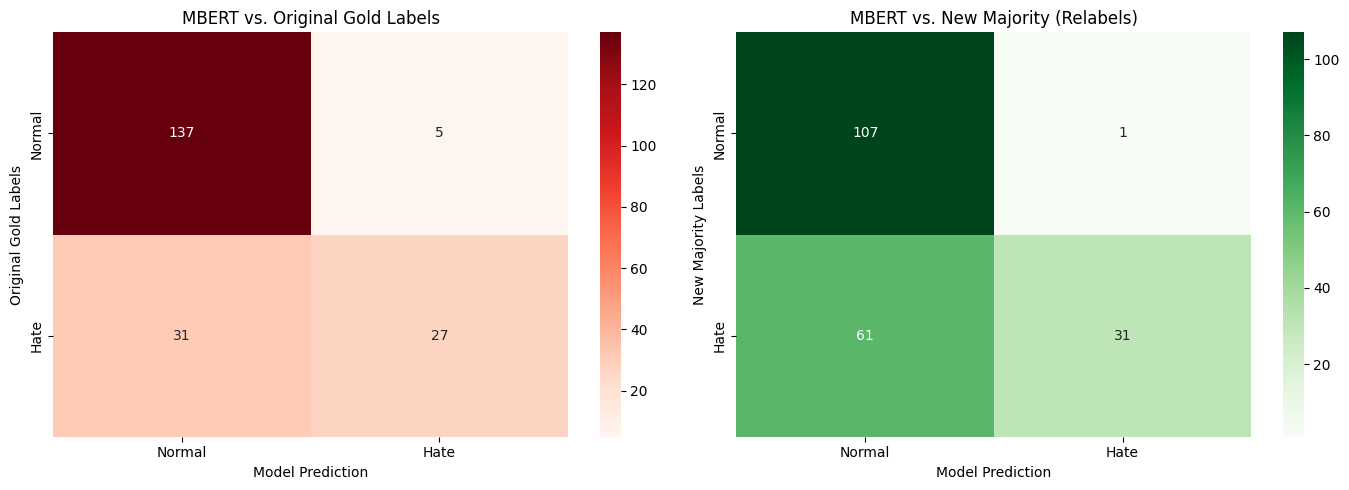


==================== AMBIGUOUS SAMPLES (PATTERN DISCOVERY) ====================
Post Text: I am Muhajir .. Aur mere lye sab se Pehly Pakistan he .. agr 10 lakh Altaf Jese leaders bh is zameen...
Original Gold: no | Human Belief Distribution [Normal, Hate]: [0.66666667 0.33333333]
------------------------------
Post Text: Poore Desh me Patel OBC me aate Hain sirf gujrat Ko chor kar may be, ye manuwadiyon bramanwadi kabhi...
Original Gold: no | Human Belief Distribution [Normal, Hate]: [0.66666667 0.33333333]
------------------------------
Post Text: Sarkar banne ke bad Hindu hit me ek bhi faisla Jo bjp ke dwara liya gaya ho,bjp ko  gay,gobar,mandir...
Original Gold: yes | Human Belief Distribution [Normal, Hate]: [0.66666667 0.33333333]
------------------------------


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report

def get_human_reproducibility(data):
    kappa = cohen_kappa_score(data["gold_label_bin"], data["majority_label_bin"])
    print(f"\n{'='*20} HUMAN REPRODUCIBILITY {'='*20}")
    print(f"Cohen’s Kappa (Gold vs. New Majority): {kappa:.4f}")

    if kappa < 0.4:
        print("Interpretation: Fair agreement. High subjectivity in Hinglish hate speech.")
    elif kappa < 0.6:
        print("Interpretation: Moderate agreement.")
    else:
        print("Interpretation: Substantial agreement.")
    return kappa

def plot_dual_confusion_matrices(m_key, y_true_gold, y_true_maj, y_pred):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm_gold = confusion_matrix(y_true_gold, y_pred)
    sns.heatmap(cm_gold, annot=True, fmt='d', cmap='Reds', ax=axes[0],
                xticklabels=['Normal', 'Hate'], yticklabels=['Normal', 'Hate'])
    axes[0].set_title(f"{m_key.upper()} vs. Original Gold Labels")
    axes[0].set_ylabel('Original Gold Labels')
    axes[0].set_xlabel('Model Prediction')

    cm_maj = confusion_matrix(y_true_maj, y_pred)
    sns.heatmap(cm_maj, annot=True, fmt='d', cmap='Greens', ax=axes[1],
                xticklabels=['Normal', 'Hate'], yticklabels=['Normal', 'Hate'])
    axes[1].set_title(f"{m_key.upper()} vs. New Majority (Relabels)")
    axes[1].set_ylabel('New Majority Labels')
    axes[1].set_xlabel('Model Prediction')

    plt.tight_layout()
    plt.show()

def generate_dissertation_summary(results_list):
    summary_df = pd.DataFrame(results_list)

    print(f"\n{'='*20} SUMMARY TABLE  {'='*20}")
    print(summary_df.to_string(index=False))

    return summary_df

def soft_label_subjectivity_analysis(data):
    def soft_calc(row):
        lbls = [row["annotator_1_bin"], row["annotator_2_bin"], row["annotator_3_bin"]]
        return np.bincount(np.array(lbls).astype(int), minlength=2) / 3.0

    data["human_belief_dist"] = data.apply(soft_calc, axis=1)

    data["reproducibility_failure"] = data["disagreement"]

    return data

kappa_val = get_human_reproducibility(df)

df = soft_label_subjectivity_analysis(df)

thesis_table = generate_dissertation_summary(summary_data)

plot_dual_confusion_matrices("mbert", y_test_gold, y_test_majority, preds)

print(f"\n{'='*20} AMBIGUOUS SAMPLES (PATTERN DISCOVERY) {'='*20}")
ambiguous = df[df["reproducibility_failure"] == 1][["text", "human_belief_dist", "gold_label"]].head(3)
for i, row in ambiguous.iterrows():
    print(f"Post Text: {row['text'][:100]}...")
    print(f"Original Gold: {row['gold_label']} | Human Belief Distribution [Normal, Hate]: {row['human_belief_dist']}")
    print("-" * 30)

## COMPLETED

In [ ]:
!pip install lime shap